# Autoencoder for Image Denoising (MNIST)

**Goal:** Build a deep learning autoencoder that removes noise from handwritten digit images (MNIST dataset).

**Approach:**
1. Load and normalize the MNIST dataset
2. Artificially corrupt images with Gaussian noise
3. Train a convolutional autoencoder to map noisy images -> clean images
4. Visualize results and evaluate reconstruction quality

**Author's note:** This notebook is an original implementation built from scratch for this assignment.

## 1. Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.21.0


## 2. Load and Preprocess the MNIST Dataset

We normalize pixel values to the range [0, 1] and reshape the images to add a channel dimension (28, 28, 1) since we will use Conv2D layers.

In [2]:
(x_train, _), (x_test, _) = mnist.load_data()

# Normalize pixel values to [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Reshape to add the channel dimension
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Train shape: (60000, 28, 28, 1)
Test shape: (10000, 28, 28, 1)


## 3. Add Noise to the Images

We add random Gaussian noise to create noisy versions of the clean images. The autoencoder's job will be to learn how to reverse this corruption.

`noise_factor` controls how strong the noise is.

In [3]:
noise_factor = 0.4

def add_noise(images, factor=noise_factor):
    noisy = images + factor * np.random.normal(loc=0.0, scale=1.0, size=images.shape)
    # Pixel values must stay within a valid [0, 1] range
    noisy = np.clip(noisy, 0.0, 1.0)
    return noisy

x_train_noisy = add_noise(x_train)
x_test_noisy = add_noise(x_test)

print("Noisy train shape:", x_train_noisy.shape)


Noisy train shape: (60000, 28, 28, 1)


### Quick look at clean vs noisy images

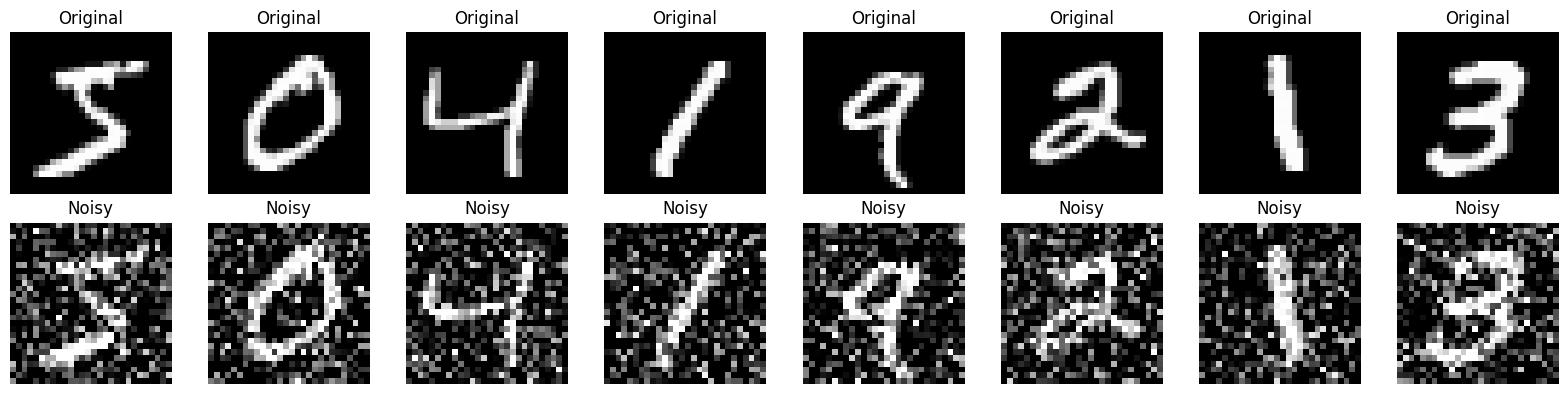

In [4]:
n = 8
plt.figure(figsize=(16, 4))
for i in range(n):
    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Noisy
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(x_train_noisy[i].reshape(28, 28), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')
plt.tight_layout()
plt.show()


## 4. Build the Convolutional Autoencoder

**Encoder:** Conv2D + MaxPooling layers progressively compress the 28x28 image into a smaller latent representation.

**Decoder:** Conv2D + UpSampling layers reconstruct the 28x28 image back from the compressed representation.

The final layer uses a `sigmoid` activation since pixel values are normalized between 0 and 1.

In [5]:
def build_autoencoder():
    input_img = keras.Input(shape=(28, 28, 1))

    # ---- Encoder ----
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
    x = layers.MaxPooling2D((2, 2), padding='same')(x)
    x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(x)
    encoded = layers.MaxPooling2D((2, 2), padding='same')(x)

    # ---- Decoder ----
    x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(encoded)
    x = layers.UpSampling2D((2, 2))(x)
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)
    decoded = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

    autoencoder = keras.Model(input_img, decoded, name="denoising_autoencoder")
    return autoencoder

autoencoder = build_autoencoder()
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
autoencoder.summary()


Model: "denoising_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 16)       │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,193 (47.63 KB)

 Trainable params: 12,193 (47.63 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Train the Autoencoder

We train the model to map **noisy images -> clean images**. This is what teaches it to denoise.

In [6]:
history = autoencoder.fit(
    x_train_noisy, x_train,
    epochs=20,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)


Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 22s 40ms/step - loss: 0.1701 - val_loss: 0.1091
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 18s 39ms/step - loss: 0.1054 - val_loss: 0.1009
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 18s 38ms/step - loss: 0.0998 - val_loss: 0.0970
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 18s 38ms/step - loss: 0.0967 - val_loss: 0.0952
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 18s 38ms/step - loss: 0.0948 - val_loss: 0.0932
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 18s 38ms/step - loss: 0.0935 - val_loss: 0.0923
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 18s 38ms/step - loss: 0.0925 - val_loss: 0.0912
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 18s 38ms/step - loss: 0.0917 - val_loss: 0.0908
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 18s 39ms/step - loss: 0.0911 - val_loss: 0.0900
Epoch 10/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 18s 38ms/step - loss: 0.0906 - val_loss: 0.0899
Epoch 11/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 18s 38ms/step - loss: 0.0902 - val_loss: 0.0892
Epoch 12/20
469/469 ━━━━━━━━━━

### Plot training vs validation loss

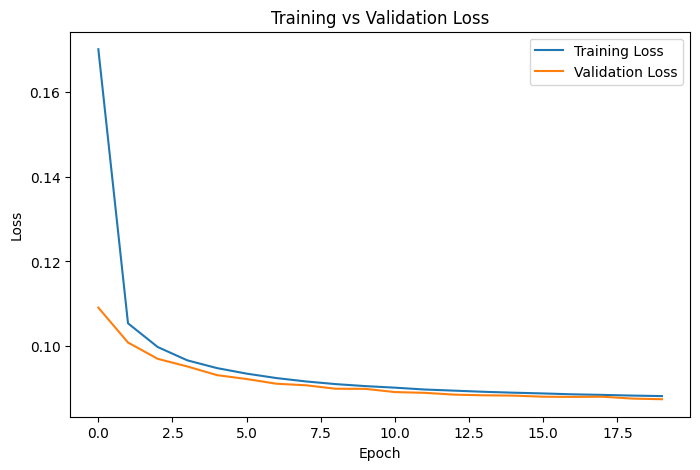

In [7]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()


## 6. Evaluate: Visualize Denoising Results

Compare the original clean image, the noisy input, and the denoised output produced by the autoencoder.

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


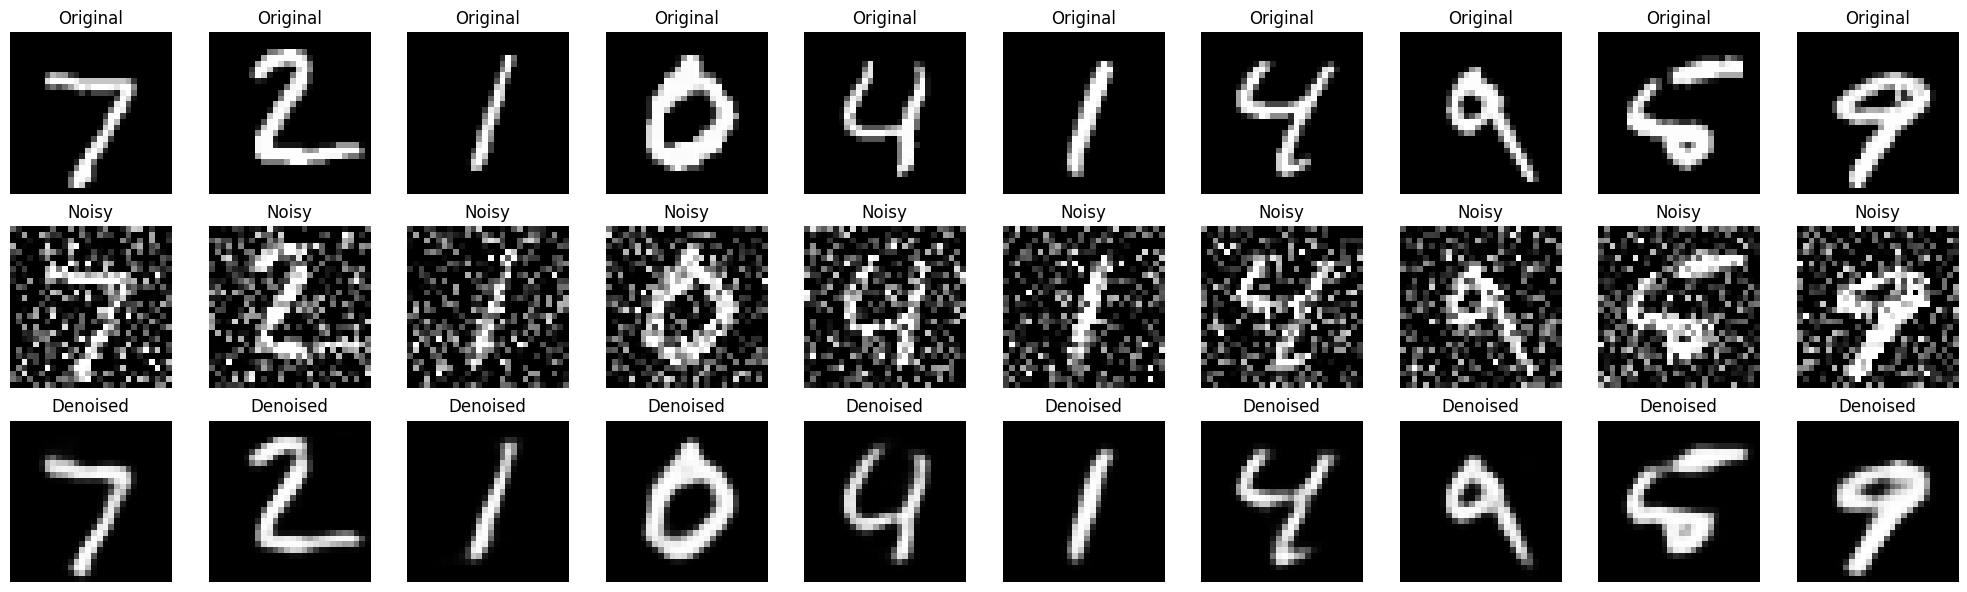

In [8]:
denoised_images = autoencoder.predict(x_test_noisy)

n = 10
plt.figure(figsize=(20, 6))
for i in range(n):
    # Original
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Noisy
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].reshape(28, 28), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

    # Denoised
    ax = plt.subplot(3, n, i + 1 + 2 * n)
    plt.imshow(denoised_images[i].reshape(28, 28), cmap='gray')
    plt.title("Denoised")
    plt.axis('off')

plt.tight_layout()
plt.show()


## 7. Quantitative Evaluation (PSNR)

Peak Signal-to-Noise Ratio (PSNR) gives a numeric measure of reconstruction quality. Higher PSNR = better denoising.

In [9]:
def psnr(original, reconstructed):
    mse = np.mean((original - reconstructed) ** 2)
    if mse == 0:
        return float('inf')
    return 20 * np.log10(1.0 / np.sqrt(mse))

noisy_psnr = psnr(x_test, x_test_noisy)
denoised_psnr = psnr(x_test, denoised_images)

print(f"PSNR (Noisy vs Original):    {noisy_psnr:.2f} dB")
print(f"PSNR (Denoised vs Original): {denoised_psnr:.2f} dB")
print(f"Improvement: {denoised_psnr - noisy_psnr:.2f} dB")


PSNR (Noisy vs Original):    10.99 dB
PSNR (Denoised vs Original): 20.81 dB
Improvement: 9.82 dB


## 8. Conclusion

- We built a convolutional autoencoder that successfully learns to remove Gaussian noise from MNIST digit images.
- The PSNR improvement between the noisy input and the denoised output confirms the model is learning meaningful denoising, not just memorizing.
- **Possible improvements:**
  - Try a deeper encoder/decoder or add BatchNormalization layers
  - Experiment with different noise types (salt-and-pepper, speckle) for robustness
  - Use SSIM as an additional evaluation metric alongside PSNR
  - Try a denoising autoencoder with skip connections (U-Net style) for sharper reconstructions
